# 第0章 動作確認

環境構築マニュアルで用意した道具が、本当に動くのかを確かめる章です。ここで確かめることは3つだけです。ライブラリがそろっているか、計算に使う装置は CPU か GPU か、そして強化学習の「環境」が画面の絵を出せるか。最後に、棒を立てる課題（CartPole）を、何も考えずにでたらめに動かしてみます。棒はすぐに倒れてしまいますが、それで構いません。次の第1章では、同じ課題を学習させて、棒を立て続けられるようにします。

- **前提**: [環境構築マニュアル](../../setup/windows_setup.md)を終えていること
- **所要の目安**: 5分
- **使う装置**: CPU だけで動きます

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ）で 2026-10-02 に実行したものです。各セルの出力がそのまま期待する結果で、その直後の「期待する結果」の段落に読み方を書いています。GPU がある環境では、装置の表示が変わります。
> - **進め方**: セルを上から順に実行します（VS Code では各セルの左の実行ボタン、または `Shift`+`Enter`）。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. 教科書で使うライブラリの版を表示して確かめられる
2. 計算に使う装置（CPU / GPU）を確かめ、後の章で使う装置を選ぶ1行の書き方が分かる
3. Gymnasium の環境を動かし、その様子を GIF に保存して見られる

完了条件は、この Notebook を上から最後まで実行して、エラーが出ずに4節の GIF が表示されることです。

## 1. ライブラリの版を確かめる

教科書で使う主なライブラリを読み込み、版を表示します。`__version__` は、多くの Python のライブラリが持っている、版の番号を表す属性です。

In [1]:
import sys

import gymnasium as gym
import imageio
import matplotlib
import numpy as np
import PIL
import stable_baselines3
import torch

print("Python           ", sys.version.split()[0])
print("Gymnasium        ", gym.__version__)
print("Stable-Baselines3", stable_baselines3.__version__)
print("PyTorch          ", torch.__version__)
print("NumPy            ", np.__version__)
print("matplotlib       ", matplotlib.__version__)
print("imageio          ", imageio.__version__)
print("Pillow           ", PIL.__version__)

Python            3.13.16
Gymnasium         1.3.0
Stable-Baselines3 2.9.0
PyTorch           2.14.1+cpu
NumPy             2.5.3
matplotlib        3.11.2
imageio           2.38.0
Pillow            12.3.0


**期待する結果**（上の出力の読み方）: Python が `3.13.`、Gymnasium が `1.3.0`、Stable-Baselines3 が `2.9.0`、PyTorch が `2.14.` で始まっていれば、環境構築マニュアルのとおりに導入できています。後から導入した場合は、より新しい版の番号になっていることがあります。最後の Pillow は、画像を扱うライブラリで、matplotlib や imageio と一緒に入ります（3-1節で使います）。

## 2. 計算に使う装置を確かめる

PyTorch は、ニューラルネットワークの計算を CPU でも NVIDIA の GPU でも行えます。`torch.cuda.is_available()` は、GPU を使える状態なら `True`、使えなければ `False` を返す関数です。

この教科書では、後の章でも、次の1行で装置を選びます。GPU があれば `"cuda"`（GPU）を、無ければ `"cpu"` を選ぶ書き方です。GPU の有無で教材のコードを書き分ける必要はありません。

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("使う装置:", device)
if device == "cuda":
    print("GPU の名前:", torch.cuda.get_device_name(0))

使う装置: cpu


**期待する結果**（上の出力の読み方）: `使う装置: cpu` なら CPU で、`使う装置: cuda` なら GPU で計算します。GPU が無くても、この章は CPU だけで最後まで動きます。後の章でも、各章の冒頭に、使う装置と CPU での学習時間の目安を書きます。GPU 版の PyTorch を入れたのに `cpu` と表示される場合は、環境構築マニュアルの5-2節の期待する結果（`torch-` の後ろの `+cu126` のような印）を見直してください。

## 3. CartPole をでたらめに動かす

**CartPole** は、左右に動く台車の上に棒を立て、倒さないように台車を動かし続ける課題です。強化学習では、このような課題の世界を**環境**と呼び、環境の中で行動を選ぶ側を**エージェント**と呼びます。

ここでは、エージェントが何も考えず、毎回でたらめに「左へ押す」か「右へ押す」かを選んだらどうなるかを見ます。次のセルの `run_random_episode` 関数は、環境を最初の状態に戻し、棒が倒れるか一定の回数に達するまで、でたらめな行動を繰り返します。1回分の試行（最初から終わりまで）を**エピソード**と呼びます。

関数の中で使っている `reset()`（最初の状態に戻す）・`step()`（行動を1つ実行する）・`render()`（今の様子を絵にする）は、Gymnasium のすべての環境に共通する操作です。`reset()` と `step()` が返す値の意味は、第2章の4節（`reset()`）と5節（`step()`）で詳しく扱います。ここでは、動かして絵が得られることだけを確かめます。

In [3]:
# でたらめな行動で1エピソードを走らせ、各時点の絵と結果を返す
def run_random_episode(env, seed):
    observation, info = env.reset(seed=seed)
    env.action_space.seed(seed)
    frames = [env.render()]
    total_reward = 0.0
    steps = 0
    while True:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        total_reward += reward
        steps += 1
        if terminated or truncated:
            return frames, total_reward, steps, terminated, truncated


env = gym.make("CartPole-v1", render_mode="rgb_array")
frames, total_reward, steps, terminated, truncated = run_random_episode(env, seed=0)

print("続いた回数:", steps)
print("得た報酬の合計:", total_reward)
print("棒が倒れて終わったか:", terminated)
print("回数の上限で終わったか:", truncated)
print("絵の大きさ（高さ, 幅, 色）:", frames[0].shape)

続いた回数: 18
得た報酬の合計: 18.0
棒が倒れて終わったか: True
回数の上限で終わったか: False
絵の大きさ（高さ, 幅, 色）: (400, 600, 3)


**期待する結果**（上の出力の読み方）:

- **続いた回数**: 棒が倒れるまでに、台車を何回動かせたか。この seed では 18 回でした。著者が seed を 0〜99 に変えて100回試したところ、平均は約 25 回、最短は 9 回、最長は 93 回で、100回中87回は 10〜40 回で倒れました
- **得た報酬の合計**: CartPole では、棒が立っている間、1回動かすごとに報酬（ほうび）が 1 もらえます。そのため、続いた回数と同じ値になります。強化学習のエージェントは、この報酬の合計を大きくすることを目指して学習します
- **棒が倒れて終わったか / 回数の上限で終わったか**: エピソードの終わり方は2種類あります。棒が倒れた（または台車が外へ出た）場合は前者、上限の 500 回に達した場合は後者が `True` になります
- **絵の大きさ**: `render_mode="rgb_array"` を指定すると、`render()` は絵を数値の配列として返します。`(400, 600, 3)` は、高さ 400、幅 600 の画素が、それぞれ赤・緑・青の3つの値を持つという意味です

`seed=0` は、でたらめの出方を固定する指定です。同じ版のライブラリで同じ値を使えば、何度実行しても同じ結果になります（ライブラリの版が変わると、結果が変わることがあります）。値を変えると、続く回数も変わります。

なお、`render_mode="human"` を指定すると、別のウィンドウで動きを見ることもできます。この教科書では、Notebook の中で結果を残すため、絵を受け取って GIF にする方法を使います。

### 3-1. 倒れたあとを、参考として見る

上の結果では、棒が倒れて終わったことになっています。ところが、最後の絵を見ても、棒は 12 度ほどしか傾いていません。CartPole は、棒の傾きが ±12 度を超えた時点で「倒れた」と判定して、エピソードを終わらせる決まりだからです。床まで倒れきるのを待たずに終わるので、絵だけを見ると、失敗したことが分かりにくくなります。

そこで、次のセルでは、失敗が一目で分かる絵を作ります。

- 判定で終わった瞬間の絵に、±12 度の線（赤）と `FAIL` の文字を書き込む
- 判定で終わったあとも、絵を作るためだけに物理の計算を続けて、棒が 80 度まで倒れる様子を描く

2つ目は、Gymnasium の本来の使い方ではありません。`terminated` が `True` になったら、`reset()` で最初の状態に戻すのが約束です。そのまま `step()` を続けると、Gymnasium は「それ以降の動きは決まっていない（未定義）」という警告を出します。ここでは、絵を作るためと分かったうえで計算を続け、その警告を表示しないようにしています。終了後の絵には `after end (ref.)`（終了後・参考）と書き込み、エピソードの中の絵と区別します。

In [4]:
import math
import warnings

from PIL import Image as PILImage
from PIL import ImageDraw, ImageFont


# 判定で終わったあとも、絵を作るためだけに物理の計算を続け、(絵, 台車の位置) の一覧を返す（参考用）
def fall_after_failure(env, choose_action, max_degrees=80, max_steps=100):
    core = env.unwrapped
    shots = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for _ in range(max_steps):
            core.step(choose_action(core.state))
            shots.append((core.render(), float(core.state[0])))
            if abs(math.degrees(core.state[2])) >= max_degrees:
                break
    return shots


# 絵に、倒れたと判定される ±12 度の線と、説明の文字を書き込む
def mark_failure(frame, cart_x, text, color):
    image = PILImage.fromarray(frame)
    draw = ImageDraw.Draw(image)
    pivot_x, pivot_y = cart_x * 125 + 300, 400 - 107.5
    for sign in (-1, 1):
        angle = math.radians(12) * sign
        tip = (pivot_x + 125 * math.sin(angle), pivot_y - 125 * math.cos(angle))
        draw.line([(pivot_x, pivot_y), tip], fill=(220, 30, 30), width=2)
    draw.text((120, 70), text, fill=color, font=ImageFont.load_default(size=30))
    return np.asarray(image)


end_x = float(env.unwrapped.state[0])
after_shots = fall_after_failure(env, lambda state: env.action_space.sample())
env.close()

failed_frame = mark_failure(frames[-1], end_x, "FAIL (> 12 deg)", (220, 30, 30))
after_frames = [mark_failure(f, x, "after end (ref.)", (110, 110, 110)) for f, x in after_shots]
print("判定で終わったあと、参考として計算を続けた回数:", len(after_shots))
print(f"そのときの棒の傾き: {math.degrees(env.unwrapped.state[2]):.0f} 度")

判定で終わったあと、参考として計算を続けた回数: 15
そのときの棒の傾き: -80 度


**期待する結果**（上の出力の読み方。seed = 0 の場合）: 判定で終わったあと、参考として計算を 15 回続けたところで、棒の傾きが -80 度（左へ 80 度）に達しました。判定の 12 度から、わずか 15 回（CartPole の中の時間で 0.3 秒）で、ほぼ横倒しになります。

コードの説明:

- `fall_after_failure` は、ラッパー（環境を包んで働きを付け足す部品。第2章の2節・6節で扱う）を外した本体（`env.unwrapped`）の `step()` を呼び続けて、棒の傾きが `max_degrees`（80 度）に達するまでの絵と、台車の位置を集めます。`warnings.catch_warnings()` と `simplefilter("ignore")` の組み合わせは、その間だけ警告を表示しない書き方です。`core.state` は、本体が内部に持っている今の状態（第2章の3節で扱う4つの数）です
- `mark_failure` は、`PIL`（画像を扱う Pillow というライブラリ）で、絵の上に線と文字を書き込みます。棒の根元の位置は、Gymnasium の描画の決まり（台車の中心が「位置 × 125 + 300」画素、棒の根元が下から約 107 画素、棒の長さが 125 画素）から計算しています
- 文字は英語にしています。日本語のフォントが無い環境でも、文字化けしないようにするためです

## 4. GIF にして見る

集めた絵を、`imageio` というライブラリで GIF アニメーションに保存します。保存先は、この Notebook と同じフォルダにある `figures` フォルダです。

In [5]:
from pathlib import Path

# エピソードの中の絵 → 判定の瞬間（少し長く止める）→ 終了後に倒れていく絵（参考）の順につなぐ
gif_frames = frames[:-1] + [failed_frame] * 10 + after_frames

gif_path = Path("figures") / "ch00_random_cartpole.gif"
gif_path.parent.mkdir(exist_ok=True)
imageio.v3.imwrite(gif_path, gif_frames, duration=100, loop=0)
print("保存した GIF:", gif_path.as_posix(), f"（{len(gif_frames)} 枚の絵）")

保存した GIF: figures/ch00_random_cartpole.gif （43 枚の絵）


**期待する結果**（上の出力の読み方。seed = 0 の場合）: `figures/ch00_random_cartpole.gif` に 43 枚の絵を書き込みます。内訳は、エピソードの中の絵 18 枚（判定の瞬間の1枚を除く）、`FAIL` の印を付けた判定の瞬間の絵 10 枚（同じ絵を並べて、1秒止める）、終了後の参考の絵 15 枚です。同じ絵が続く所は、GIF の保存に使われる Pillow が1枚にまとめて、表示時間を足し合わせます。そのため、保存されたファイルの中の枚数は、書き込んだ枚数より少なくなります。見え方は変わりません。著者の環境では、ファイルの中は 32 枚、再生の時間は合わせて 4.3 秒でした。

`duration=100` は、絵を1枚あたり 100 ミリ秒ずつ表示する（1秒あたり 10 枚）指定です。CartPole の中の時間は1回の行動あたり 0.02 秒なので、この GIF は実際の5倍ゆっくり再生されます。倒れていく様子を目で追いやすくするためです。`loop=0` は、アニメーションを繰り返し再生する指定です。

保存した GIF を、Notebook の中に表示します。`IPython.display.Image` は、画像のファイルを読み込み、セルの出力として Notebook の中に表示する機能です。

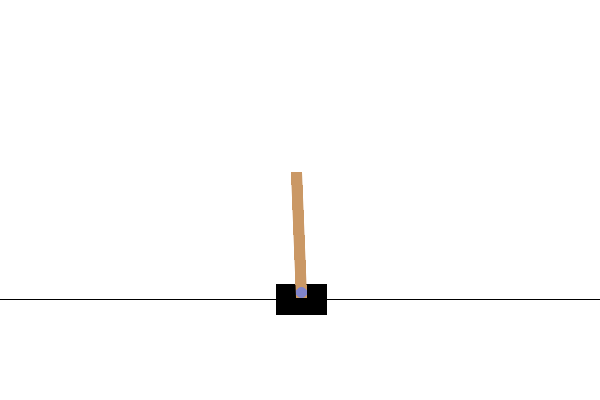

In [6]:
from IPython.display import Image

Image(filename=gif_path)

**期待する結果**（VS Code などで実行した場合）: CartPole の GIF が繰り返し再生されます。棒が少しずつ傾き、±12 度の赤い線を越えたところで `FAIL` と表示されて少し止まります。そのあと、参考として、棒が大きく倒れていく様子が続きます。

GitHub でこの Notebook を開いても、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。動く様子は、この章のフォルダの [README.md](README.md) で見られます。

Notebook の中でも流れが分かるように、次のセルで、GIF の中から6枚の絵を選んで横に並べた「コマ送り」の図を作ります。

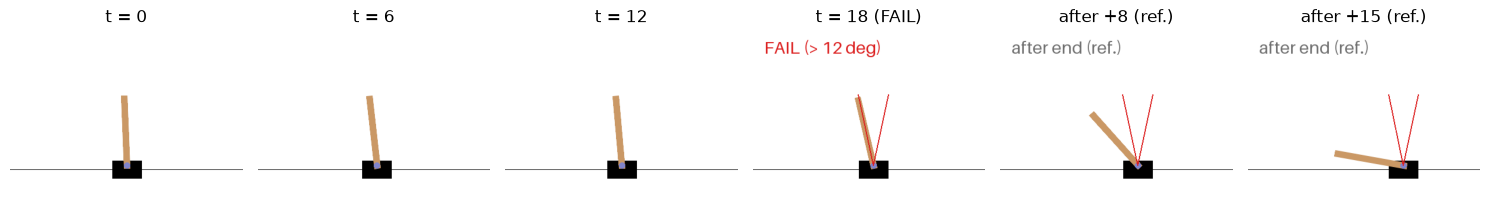

In [7]:
import matplotlib.pyplot as plt

# エピソードの中から4枚（最後は判定の瞬間）、終了後の参考から2枚を選び、台車と棒のまわりを切り出して横に並べる
episode_picks = np.linspace(0, len(frames) - 1, 4).round().astype(int)
panels = [(frames[i], f"t = {i}") for i in episode_picks[:-1]]
panels.append((failed_frame, f"t = {episode_picks[-1]} (FAIL)"))
middle = len(after_frames) // 2
panels.append((after_frames[middle], f"after +{middle + 1} (ref.)"))
panels.append((after_frames[-1], f"after +{len(after_frames)} (ref.)"))

fig, axes = plt.subplots(1, len(panels), figsize=(15, 3.2))
for ax, (image, title) in zip(axes, panels):
    ax.imshow(image[60:350, 100:500])
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
fig.savefig(Path("figures") / "ch00_random_cartpole_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方。seed = 0 の場合）: 左から右へ時間が進みます。左の4枚はエピソードの中の絵で、`t` はエピソードの始まりから何回行動したかを表します（`t = 0, 6, 12, 18`）。棒は少しずつ左へ傾いていき、`t = 18` で ±12 度の赤い線を越えて、倒れたと判定されます（`FAIL`）。右の2枚は終了後の参考の絵で、判定から 8 回と 15 回、計算を続けたときの様子です。棒は左へ大きく倒れ、15 回後には 80 度まで傾いています。

コードの説明:

- `np.linspace(0, len(frames) - 1, 4)` は、0 から最後の絵の番号（この seed では 18）までを等間隔に分けた4つの数を作る関数です。`.round().astype(int)` で整数に丸めるので、この seed では `t = 0, 6, 12, 18` の絵が選ばれます。最後の1枚は、`FAIL` の印を付けた絵に差し替えています
- 終了後の参考の絵からは、真ん中の1枚と最後の1枚を選んでいます
- `plt.subplots(1, 6)` は、横1行に6つの描画領域を作る関数です。`imshow` で各領域に絵を表示し、`axis("off")` で目盛りを消しています
- `image[60:350, 100:500]` は、絵（高さ 400 × 幅 600）のうち、縦 60〜349、横 100〜499 の画素を切り出す書き方です。seed = 0 で、台車と、倒れていく棒と、書き込んだ文字が入るように選んだ範囲です。seed を変えて長く続くエピソードでは、台車が左右に動いて、この範囲の外に出ることがあります
- `fig.tight_layout()` は、描画領域どうしの間隔を自動で整える関数です。`fig.savefig(..., dpi=80)` は、図を `figures/ch00_random_cartpole_frames.png` に保存します（`dpi` は画像の細かさの指定です）

## 5. まとめ

この章では、次のことを確かめました。

| 確かめたこと | 使ったもの |
|---|---|
| ライブラリの版 | 各ライブラリの `__version__` |
| 計算に使う装置 | `torch.cuda.is_available()` と、装置を選ぶ1行 |
| 環境が動き、絵を出せること | `gym.make()`・`reset()`・`step()`・`render()` |
| 動きを GIF で残せること | `imageio.v3.imwrite()`・`IPython.display.Image` |
| 動きをコマ送りの図にできること | matplotlib の `plt.subplots()`・`imshow()` |
| 失敗した様子を分かりやすく見せること | ±12 度の線と `FAIL` の書き込み（Pillow）、終了後の参考の絵 |

でたらめに動かした台車では、棒はすぐに倒れてしまいました。次の第1章では、同じ CartPole を、Stable-Baselines3 というライブラリの学習アルゴリズムで数分だけ学習させます。学習の前と後で、棒の立ち方がどう変わるかを見比べます。

- 次に読むもの: [第1章 動かして楽しむ](../ch01_first_training/ch01_first_training.ipynb)

## 出典

この章は、次の公式の文書（2026-10-01 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。

- Farama Foundation, Gymnasium Documentation（CartPole の環境の説明）: https://gymnasium.farama.org/environments/classic_control/cart_pole/
- Farama Foundation, Gymnasium 1.3.0 のソース `gymnasium/envs/classic_control/cartpole.py`（描画の大きさの決まり、判定のあとの `step()` で出る警告）: https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/classic_control/cartpole.py
- PyTorch, `torch.cuda.is_available` の定義（公式リポジトリの v2.14.1 の `torch/cuda/__init__.py`）: https://github.com/pytorch/pytorch/blob/v2.14.1/torch/cuda/__init__.py

4節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の CartPole の描画処理が出力したものに、著者が Pillow で線と文字を書き込んだものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。